In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import defaultdict
import copy
import os
import pprint
import functools

import hydra
import duckdb
from omegaconf import OmegaConf
from einops import rearrange
import numpy as np
import pandas as pd
import seaborn as sns
sns.set_theme(style='whitegrid', font_scale=2, palette=sns.color_palette('Set2'),)
import sqlalchemy as sa
import marimo as mo
import seaborn as sns
import lightning.pytorch
import polars as pl
from tqdm import tqdm
import torch

from conf import conf
from dafm import datasets, models, plots, utils

In [3]:
duckdb.sql("""
attach '../runs.sqlite';
use runs;
""")

In [4]:
engine = conf.get_engine()
session = conf.sa.orm.Session(engine)
session.begin()

In [45]:
# Benchmark
# KuramotoSivashinsky
# alt_ids = duckdb.sql(f"""
# select
#     alt_id, label, rng_seed
# from (
#     select Model.id, 'EnSF' as label from Model join ScoreMatchingMarginal on Model.id = ScoreMatchingMarginal.id where sampling_time_step_count = 20 and sampling_score_norm = 'LInfty'
#     union
#     select Model.id, 'EnFF-OT' as label from Model join FlowMatchingMarginal on Model.id = FlowMatchingMarginal.id join ConditionalOptimalTransport on FlowMatchingMarginal.DiffusionPath = ConditionalOptimalTransport.id join Local on FlowMatchingMarginal.EnergyGuidance = Local.id join Constant on Local.Schedule = Constant.id where sampling_time_step_count = 20 and sampler = 'EULER' and sigma_min = 0.01 and constant = 1.
#     union
#     select Model.id, 'EnFF-F2P' as label from Model join FlowMatchingMarginal on Model.id = FlowMatchingMarginal.id join PreviousPosteriorToPredictive on FlowMatchingMarginal.DiffusionPath = PreviousPosteriorToPredictive.id join Local on FlowMatchingMarginal.EnergyGuidance = Local.id join Constant on Local.Schedule = Constant.id where sampling_time_step_count = 20 and sampler = 'EULER' and sigma_min = 0.01 and constant = .2
#     union
#     select Model.id, 'EnKF-PO' as label from Model join EnsembleKalmanFilterPerturbedObservations on Model.id = EnsembleKalmanFilterPerturbedObservations.id join ConstantScale on Model.InflationScale = ConstantScale.id where constant = 1.0 and loc_radius_gc = 8.0
#     union
#     select Model.id, 'EnKF-RSR' as label from Model join EnsembleRandomizedSquareRootFilter on Model.id = EnsembleRandomizedSquareRootFilter.id join ConstantScale on Model.InflationScale = ConstantScale.id where constant = 1.0 and loc_radius_gc = 8.0
#     union
#     select Model.id, 'LETKF' as label from Model join LocalEnsembleTransformKalmanFilter on Model.id = LocalEnsembleTransformKalmanFilter.id join ConstantScale on Model.InflationScale = ConstantScale.id where constant = 1.0 and loc_radius_gc = 8.0
#     union
#     select Model.id, 'BPF' as label from Model join BootstrapParticleFilter on Model.id = BootstrapParticleFilter.id join ConstantScale on Model.InflationScale = ConstantScale.id where constant = 1.5
# ) as all_models
# join Conf on Conf.Model = all_models.id
# join Dataset on Conf.Dataset = Dataset.id
# join KuramotoSivashinsky on Dataset.id = KuramotoSivashinsky.id
# where state_dimension in (256, 512, 1024) and predicted_state_initial_condition_std = 1.0 and predicted_state_count = 20
# order by state_dimension, rng_seed, floating_point_precision, label
# """).pl()
# NavierStokes
# alt_ids = duckdb.sql(f"""
# select
#     alt_id, label, rng_seed
# from (
#     select Model.id, 'EnSF' as label from Model join ScoreMatchingMarginal on Model.id = ScoreMatchingMarginal.id where sampling_time_step_count = 50 and sampling_score_norm = 'LInfty'
#     union
#     select Model.id, 'EnFF-OT' as label from Model join FlowMatchingMarginal on Model.id = FlowMatchingMarginal.id join ConditionalOptimalTransport on FlowMatchingMarginal.DiffusionPath = ConditionalOptimalTransport.id join Local on FlowMatchingMarginal.EnergyGuidance = Local.id join Constant on Local.Schedule = Constant.id where sampling_time_step_count = 50 and sampler = 'EULER' and sigma_min = 0.01 and constant = 1.
#     union
#     select Model.id, 'EnFF-F2P' as label from Model join FlowMatchingMarginal on Model.id = FlowMatchingMarginal.id join PreviousPosteriorToPredictive on FlowMatchingMarginal.DiffusionPath = PreviousPosteriorToPredictive.id join Local on FlowMatchingMarginal.EnergyGuidance = Local.id join Constant on Local.Schedule = Constant.id where sampling_time_step_count = 50 and sampler = 'EULER' and sigma_min = 0.01 and constant = .2
#     union
#     select Model.id, 'EnKF-PO' as label from Model join EnsembleKalmanFilterPerturbedObservations on Model.id = EnsembleKalmanFilterPerturbedObservations.id join ConstantScale on Model.InflationScale = ConstantScale.id where constant = 1.1 and loc_radius_gc = 8.0
#     union
#     select Model.id, 'EnKF-RSR' as label from Model join EnsembleRandomizedSquareRootFilter on Model.id = EnsembleRandomizedSquareRootFilter.id join ConstantScale on Model.InflationScale = ConstantScale.id where constant = 1.7 and loc_radius_gc = 8.0
#     union
#     select Model.id, 'LETKF' as label from Model join LocalEnsembleTransformKalmanFilter on Model.id = LocalEnsembleTransformKalmanFilter.id join ConstantScale on Model.InflationScale = ConstantScale.id where constant = 1.0 and loc_radius_gc = 6.0
# ) as all_models
# join Conf on Conf.Model = all_models.id
# join Dataset on Conf.Dataset = Dataset.id
# join NavierStokes on Dataset.id = NavierStokes.id
# where state_dimension in (3*10*10, 3*64*64, 3*256*256) and predicted_state_initial_condition_std = 1.0 and predicted_state_count = 20
# order by state_dimension, rng_seed, label
# """).pl()
# Ablation study
# KuramotoSivashinsky
# Sigma min
# alt_ids = duckdb.sql("""
# select
#     alt_id, label, rng_seed
# from (
#     select Model.id, 'EnFF-OT' as label from Model join FlowMatchingMarginal on Model.id = FlowMatchingMarginal.id join ConditionalOptimalTransport on FlowMatchingMarginal.DiffusionPath = ConditionalOptimalTransport.id join Local on FlowMatchingMarginal.EnergyGuidance = Local.id join Constant on Local.Schedule = Constant.id where sampling_time_step_count = 20 and sampler = 'EULER' and sigma_min in (0.5, 0.1, 0.01, 0.001, 0.0001, 0.00001) and constant = 1.
#     union
#     select Model.id, 'EnFF-F2P' as label from Model join FlowMatchingMarginal on Model.id = FlowMatchingMarginal.id join PreviousPosteriorToPredictive on FlowMatchingMarginal.DiffusionPath = PreviousPosteriorToPredictive.id join Local on FlowMatchingMarginal.EnergyGuidance = Local.id join Constant on Local.Schedule = Constant.id where sampling_time_step_count = 20 and sampler = 'EULER' and sigma_min in (0.5, 0.1, 0.01, 0.001, 0.0001, 0.00001) and constant = .2
# ) as all_models
# join Conf on Conf.Model = all_models.id
# join Dataset on Conf.Dataset = Dataset.id
# join KuramotoSivashinsky on Dataset.id = KuramotoSivashinsky.id
# where state_dimension in (256, 512, 1024) and predicted_state_initial_condition_std = 1.0 and predicted_state_count = 20
# order by state_dimension, rng_seed, floating_point_precision, label
# """).pl()
# Guidance schedule
# alt_ids = duckdb.sql("""
# select
#     alt_id, label, rng_seed
# from (
#     select Model.id, 'EnFF-OT' as label from Model join FlowMatchingMarginal on Model.id = FlowMatchingMarginal.id join ConditionalOptimalTransport on FlowMatchingMarginal.DiffusionPath = ConditionalOptimalTransport.id join Local on FlowMatchingMarginal.EnergyGuidance = Local.id join Constant on Local.Schedule = Constant.id where sampling_time_step_count = 20 and sampler = 'EULER' and sigma_min = 0.01 and constant in (0.05, 0.1, 0.2, 0.5, 1.0, 2.0)
#     union
#     select Model.id, 'EnFF-F2P' as label from Model join FlowMatchingMarginal on Model.id = FlowMatchingMarginal.id join PreviousPosteriorToPredictive on FlowMatchingMarginal.DiffusionPath = PreviousPosteriorToPredictive.id join Local on FlowMatchingMarginal.EnergyGuidance = Local.id join Constant on Local.Schedule = Constant.id where sampling_time_step_count = 20 and sampler = 'EULER' and sigma_min = 0.01 and constant in (0.05, 0.1, 0.2, 0.5, 1.0, 2.0) and use_independent_coupling = false
# ) as all_models
# join Conf on Conf.Model = all_models.id
# join Dataset on Conf.Dataset = Dataset.id
# join KuramotoSivashinsky on Dataset.id = KuramotoSivashinsky.id
# where state_dimension = 1024 and predicted_state_initial_condition_std = 1.0 and predicted_state_count = 20
# order by state_dimension, rng_seed, floating_point_precision, label
# """).pl()
# NavierStokes
# Sigma min
# alt_ids = duckdb.sql("""
# select
#     alt_id, label, rng_seed
# from (
#     select Model.id, 'EnFF-OT' as label from Model join FlowMatchingMarginal on Model.id = FlowMatchingMarginal.id join ConditionalOptimalTransport on FlowMatchingMarginal.DiffusionPath = ConditionalOptimalTransport.id join Local on FlowMatchingMarginal.EnergyGuidance = Local.id join Constant on Local.Schedule = Constant.id where sampling_time_step_count = 50 and sampler = 'EULER' and sigma_min in (0.5, 0.1, 0.01, 0.001, 0.0001, 0.00001) and constant = 1.
#     union
#     select Model.id, 'EnFF-F2P' as label from Model join FlowMatchingMarginal on Model.id = FlowMatchingMarginal.id join PreviousPosteriorToPredictive on FlowMatchingMarginal.DiffusionPath = PreviousPosteriorToPredictive.id join Local on FlowMatchingMarginal.EnergyGuidance = Local.id join Constant on Local.Schedule = Constant.id where sampling_time_step_count = 50 and sampler = 'EULER' and sigma_min in (0.5, 0.1, 0.01, 0.001, 0.0001, 0.00001) and constant = .2
# ) as all_models
# join Conf on Conf.Model = all_models.id
# join Dataset on Conf.Dataset = Dataset.id
# join NavierStokes on Dataset.id = NavierStokes.id
# where state_dimension = 3*256*256 and predicted_state_initial_condition_std = 1.0 and predicted_state_count = 20
# order by state_dimension, rng_seed, label
# """).pl()
# Guidance schedule
# alt_ids = duckdb.sql("""
# select
#     alt_id, label, rng_seed
# from (
#     select Model.id, 'EnFF-OT' as label from Model join FlowMatchingMarginal on Model.id = FlowMatchingMarginal.id join ConditionalOptimalTransport on FlowMatchingMarginal.DiffusionPath = ConditionalOptimalTransport.id join Local on FlowMatchingMarginal.EnergyGuidance = Local.id join Constant on Local.Schedule = Constant.id where sampling_time_step_count = 50 and sampler = 'EULER' and sigma_min = 0.01 and constant in (0.05, 0.1, 0.2, 0.5, 1.0, 2.0)
#     union
#     select Model.id, 'EnFF-F2P' as label from Model join FlowMatchingMarginal on Model.id = FlowMatchingMarginal.id join PreviousPosteriorToPredictive on FlowMatchingMarginal.DiffusionPath = PreviousPosteriorToPredictive.id join Local on FlowMatchingMarginal.EnergyGuidance = Local.id join Constant on Local.Schedule = Constant.id where sampling_time_step_count = 50 and sampler = 'EULER' and sigma_min = 0.01 and constant in (0.05, 0.1, 0.2, 0.5, 1.0, 2.0)
# ) as all_models
# join Conf on Conf.Model = all_models.id
# join Dataset on Conf.Dataset = Dataset.id
# join NavierStokes on Dataset.id = NavierStokes.id
# where state_dimension = 3*256*256 and predicted_state_initial_condition_std = 1.0 and predicted_state_count = 20
# order by state_dimension, rng_seed, label
# """).pl()
alt_ids

alt_id,label,rng_seed
str,str,i64
"""ixh91uzq""","""EnFF-F2P""",97616566
"""b9z2shrn""","""EnFF-F2P""",97616566
"""fv3byhuv""","""EnFF-F2P""",97616566
"""2yb8gdym""","""EnFF-F2P""",97616566
"""iron71a3""","""EnFF-F2P""",97616566
…,…,…
"""zsw3xgnf""","""EnFF-OT""",2376999025
"""p8kmlr23""","""EnFF-OT""",2376999025
"""jprexk2s""","""EnFF-OT""",2376999025


In [46]:
cfgs = session.execute(sa.select(conf.Conf).where(conf.Conf.alt_id.in_(alt_ids.get_column('alt_id'))))
cfgs = {c.alt_id: c for (c,) in cfgs}
rng_seeds = []
cfg_dataset = None
for alt_id in alt_ids.get_column('alt_id'):
    cfg = cfgs[alt_id]
    if cfg_dataset is None:
        cfg_dataset = cfg.dataset
    assert isinstance(cfg.dataset, cfg_dataset.__class__)
    rng_seeds.append(cfg.rng_seed)
rng_seeds = np.array(rng_seeds)
# assert (np.diff(rng_seeds) >= 0).all(), 'rng_seeds must be monotonically non-decreasing for dataset caching'

In [47]:
@functools.lru_cache(maxsize=1)
def get_true_state(cfg_dataset, rng_seed):
    lightning.pytorch.seed_everything(rng_seed)
    with lightning.pytorch.utilities.seed.isolate_rng():
        dynamics = datasets.get_dynamics_dataset(cfg_dataset, device=cfg.device)
    true_state = pl.DataFrame(
        torch.cat([dynamics.times, dynamics.true_state[:, 0]], dim=1).cpu().numpy(),
        schema=['times', *(f'true_state_dim_{d}' for d in range(dynamics.true_state[:, 0].shape[1]))],
    )
    del dynamics
    if 'cuda' in cfg.device:
        torch.cuda.empty_cache()
    return true_state

In [48]:
rmses = []
for alt_id in alt_ids.get_column('alt_id'):
    print(alt_id)
    cfg = cfgs[alt_id]
    
    if not (cfg.run_dir/f'{cfg.prediction_filename}.parquet').exists():
        continue

    true_state = get_true_state(cfg.dataset, cfg.rng_seed)

    alt_id_row = alt_ids.filter(alt_id=alt_id)
    
    rmse = (
        pl.scan_parquet(
            cfg.run_dir/f'{cfg.prediction_filename}.parquet',
        )
        # take last X time steps when data assimilation occurred
        .sort('times')
        .gather_every(cfg.dataset.observe_every_n_time_steps, offset=1)  # offset to exclude initial condition
        .tail(50)
        
        .join(true_state.lazy(), on='times')
        .select(
            pl.lit(alt_id).alias('alt_id'),
            pl.lit(alt_id_row.get_column('label').item()).alias('label'),
            pl.lit(cfg.rng_seed, dtype=pl.datatypes.Int64).alias('rng_seed'),
            pl.col('times'),
            pl.lit(cfg.dataset.state_dimension).alias('Dimension'),
            pl.lit(cfg.model.diffusion_path.sigma_min).alias('sigma_min'),
            pl.lit(cfg.model.guidance.schedule.constant).alias('lambda'),
            pl.mean_horizontal(
                (
                    pl.col(f'predicted_state_mean_dim_{d}') - pl.col(f'true_state_dim_{d}')
                ).pow(2)
                for d in range(cfg.dataset.state_dimension)
            ).sqrt().alias('RMSE(dim)'),
        )
        .group_by('alt_id', 'label', 'rng_seed', 'Dimension', 'sigma_min', 'lambda')
        .agg(pl.col('RMSE(dim)').mean().alias('Mean(time) RMSE(dim)').alias('RMSE'))
        .collect()
    )
    print(rmse)
    rmses.append(rmse)
    
rmses = pl.concat(rmses)
rmses

ixh91uzq


Seed set to 97616566


shape: (1, 7)
┌──────────┬──────────┬──────────┬───────────┬───────────┬────────┬──────────┐
│ alt_id   ┆ label    ┆ rng_seed ┆ Dimension ┆ sigma_min ┆ lambda ┆ RMSE     │
│ ---      ┆ ---      ┆ ---      ┆ ---       ┆ ---       ┆ ---    ┆ ---      │
│ str      ┆ str      ┆ i64      ┆ i32       ┆ f64       ┆ f64    ┆ f32      │
╞══════════╪══════════╪══════════╪═══════════╪═══════════╪════════╪══════════╡
│ ixh91uzq ┆ EnFF-F2P ┆ 97616566 ┆ 196608    ┆ 0.01      ┆ 2.0    ┆ 0.339889 │
└──────────┴──────────┴──────────┴───────────┴───────────┴────────┴──────────┘
b9z2shrn
shape: (1, 7)
┌──────────┬──────────┬──────────┬───────────┬───────────┬────────┬──────────┐
│ alt_id   ┆ label    ┆ rng_seed ┆ Dimension ┆ sigma_min ┆ lambda ┆ RMSE     │
│ ---      ┆ ---      ┆ ---      ┆ ---       ┆ ---       ┆ ---    ┆ ---      │
│ str      ┆ str      ┆ i64      ┆ i32       ┆ f64       ┆ f64    ┆ f32      │
╞══════════╪══════════╪══════════╪═══════════╪═══════════╪════════╪══════════╡
│ b9z2shrn ┆ En

Seed set to 462133975


shape: (1, 7)
┌──────────┬──────────┬───────────┬───────────┬───────────┬────────┬──────────┐
│ alt_id   ┆ label    ┆ rng_seed  ┆ Dimension ┆ sigma_min ┆ lambda ┆ RMSE     │
│ ---      ┆ ---      ┆ ---       ┆ ---       ┆ ---       ┆ ---    ┆ ---      │
│ str      ┆ str      ┆ i64       ┆ i32       ┆ f64       ┆ f64    ┆ f32      │
╞══════════╪══════════╪═══════════╪═══════════╪═══════════╪════════╪══════════╡
│ z3d2wlno ┆ EnFF-F2P ┆ 462133975 ┆ 196608    ┆ 0.01      ┆ 2.0    ┆ 0.383341 │
└──────────┴──────────┴───────────┴───────────┴───────────┴────────┴──────────┘
68nb8bih
shape: (1, 7)
┌──────────┬──────────┬───────────┬───────────┬───────────┬────────┬──────────┐
│ alt_id   ┆ label    ┆ rng_seed  ┆ Dimension ┆ sigma_min ┆ lambda ┆ RMSE     │
│ ---      ┆ ---      ┆ ---       ┆ ---       ┆ ---       ┆ ---    ┆ ---      │
│ str      ┆ str      ┆ i64       ┆ i32       ┆ f64       ┆ f64    ┆ f32      │
╞══════════╪══════════╪═══════════╪═══════════╪═══════════╪════════╪══════════╡
│ 6

...

Seed set to 979497033


shape: (1, 7)
┌──────────┬──────────┬───────────┬───────────┬───────────┬────────┬──────┐
│ alt_id   ┆ label    ┆ rng_seed  ┆ Dimension ┆ sigma_min ┆ lambda ┆ RMSE │
│ ---      ┆ ---      ┆ ---       ┆ ---       ┆ ---       ┆ ---    ┆ ---  │
│ str      ┆ str      ┆ i64       ┆ i32       ┆ f64       ┆ f64    ┆ f32  │
╞══════════╪══════════╪═══════════╪═══════════╪═══════════╪════════╪══════╡
│ 9ea6apul ┆ EnFF-F2P ┆ 979497033 ┆ 196608    ┆ 0.01      ┆ 2.0    ┆ NaN  │
└──────────┴──────────┴───────────┴───────────┴───────────┴────────┴──────┘
s5f4vdkr
shape: (1, 7)
┌──────────┬──────────┬───────────┬───────────┬───────────┬────────┬──────┐
│ alt_id   ┆ label    ┆ rng_seed  ┆ Dimension ┆ sigma_min ┆ lambda ┆ RMSE │
│ ---      ┆ ---      ┆ ---       ┆ ---       ┆ ---       ┆ ---    ┆ ---  │
│ str      ┆ str      ┆ i64       ┆ i32       ┆ f64       ┆ f64    ┆ f32  │
╞══════════╪══════════╪═══════════╪═══════════╪═══════════╪════════╪══════╡
│ s5f4vdkr ┆ EnFF-F2P ┆ 979497033 ┆ 196608    ┆ 0.0

Seed set to 2376999025


shape: (1, 7)
┌──────────┬──────────┬────────────┬───────────┬───────────┬────────┬──────────┐
│ alt_id   ┆ label    ┆ rng_seed   ┆ Dimension ┆ sigma_min ┆ lambda ┆ RMSE     │
│ ---      ┆ ---      ┆ ---        ┆ ---       ┆ ---       ┆ ---    ┆ ---      │
│ str      ┆ str      ┆ i64        ┆ i32       ┆ f64       ┆ f64    ┆ f32      │
╞══════════╪══════════╪════════════╪═══════════╪═══════════╪════════╪══════════╡
│ hwr178gw ┆ EnFF-F2P ┆ 2376999025 ┆ 196608    ┆ 0.01      ┆ 2.0    ┆ 0.368148 │
└──────────┴──────────┴────────────┴───────────┴───────────┴────────┴──────────┘
gt8e5kkw
shape: (1, 7)
┌──────────┬──────────┬────────────┬───────────┬───────────┬────────┬──────────┐
│ alt_id   ┆ label    ┆ rng_seed   ┆ Dimension ┆ sigma_min ┆ lambda ┆ RMSE     │
│ ---      ┆ ---      ┆ ---        ┆ ---       ┆ ---       ┆ ---    ┆ ---      │
│ str      ┆ str      ┆ i64        ┆ i32       ┆ f64       ┆ f64    ┆ f32      │
╞══════════╪══════════╪════════════╪═══════════╪═══════════╪════════╪═══

alt_id,label,rng_seed,Dimension,sigma_min,lambda,RMSE
str,str,i64,i32,f64,f64,f32
"""ixh91uzq""","""EnFF-F2P""",97616566,196608,0.01,2.0,0.339889
"""b9z2shrn""","""EnFF-F2P""",97616566,196608,0.01,0.5,0.173342
"""fv3byhuv""","""EnFF-F2P""",97616566,196608,0.01,0.1,0.142365
"""2yb8gdym""","""EnFF-F2P""",97616566,196608,0.01,0.05,0.121593
"""iron71a3""","""EnFF-F2P""",97616566,196608,0.01,0.2,0.158183
…,…,…,…,…,…,…
"""gt8e5kkw""","""EnFF-F2P""",2376999025,196608,0.01,0.5,0.160469
"""42hz2bqx""","""EnFF-F2P""",2376999025,196608,0.01,0.05,0.117119
"""6nv7zg8y""","""EnFF-F2P""",2376999025,196608,0.01,0.1,0.13267


In [49]:
rmses

alt_id,label,rng_seed,Dimension,sigma_min,lambda,RMSE
str,str,i64,i32,f64,f64,f32
"""ixh91uzq""","""EnFF-F2P""",97616566,196608,0.01,2.0,0.339889
"""b9z2shrn""","""EnFF-F2P""",97616566,196608,0.01,0.5,0.173342
"""fv3byhuv""","""EnFF-F2P""",97616566,196608,0.01,0.1,0.142365
"""2yb8gdym""","""EnFF-F2P""",97616566,196608,0.01,0.05,0.121593
"""iron71a3""","""EnFF-F2P""",97616566,196608,0.01,0.2,0.158183
…,…,…,…,…,…,…
"""gt8e5kkw""","""EnFF-F2P""",2376999025,196608,0.01,0.5,0.160469
"""42hz2bqx""","""EnFF-F2P""",2376999025,196608,0.01,0.05,0.117119
"""6nv7zg8y""","""EnFF-F2P""",2376999025,196608,0.01,0.1,0.13267


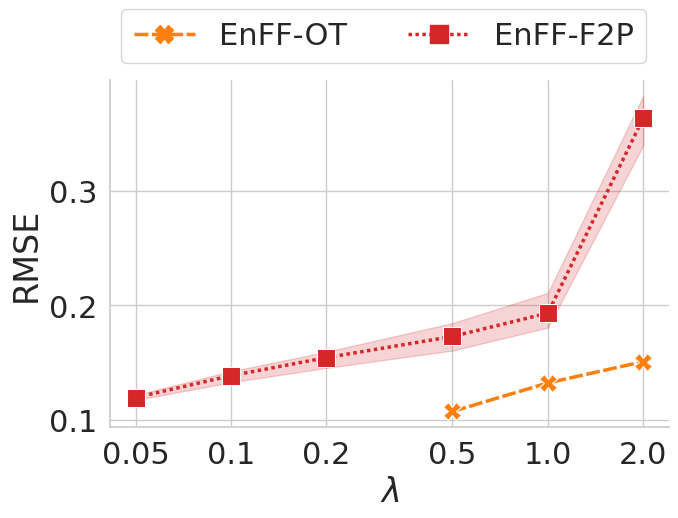

In [50]:
xticks = rmses.select(pl.col('lambda').unique()).to_numpy().squeeze()
xticklabels = xticks
# xticklabels = [rf'${int(x)} \times {int(x)}$' for x in np.sqrt(xticks / 3)]
# yticks = list(torch.linspace(.1, 15, 20).numpy())[::2]
# hue_order = ['EnSF', 'EnFF-OT', 'EnFF-F2P', 'BPF', 'EnKF-PO', 'EnKF-RSR', 'LETKF']
hue_order = ['EnFF-OT', 'EnFF-F2P']
plot_rmse = (
    sns.relplot(
        kind='line',
        data=rmses,
        x='lambda',
        y='RMSE',
        hue='label',
        hue_order=hue_order,
        style_order=hue_order,
        style='label',
        palette={
            'EnSF': 'tab:gray',
            'EnFF-OT': 'tab:orange',
            'EnFF-F2P': 'tab:red',
            'BPF': 'tab:olive',
            'EnKF-PO': 'tab:pink',
            'EnKF-RSR': 'tab:purple',
            'LETKF': 'tab:green',
        },
        errorbar=('pi', 100),
        markers={
            'EnFF-OT': 'X',
            'EnFF-F2P': 's',
        },
        dashes={
            'EnFF-OT': (4, 1),
            'EnFF-F2P': (1, 1),
        },
        markersize=12.5,
        linewidth=2.5,
        # height=6,
        aspect=1.5,
    )
    .set(
        # ylim=(0, 1),
        xscale='log',
        # yscale='log',
        xticks=xticks,
        xticklabels=xticklabels,
        # yticks=yticks,
        # yticklabels=yticks,
    )
)
# ax_twin = plot_rmse.axes[0][0].twinx()
# ax_twin.set_axis_off()
sns.move_legend(
    plot_rmse,
    loc='upper center',
    ncol=len(hue_order),
    title='',
    bbox_to_anchor=(.455, 1.10),
    frameon=True,
    fancybox=True,
)
for (row, col, hue), _ in plot_rmse.facet_data():
    ax = plot_rmse.axes[row][col]
    ax.xaxis.minorticks_off()
    ax.set_xlabel(r'$\lambda$')

In [51]:
plots.save_all_subfigures(plot_rmse, 'RMSEByGuidanceSchedule')

In [12]:
# alt_ids = {
#     # Lorenz96Bao2024EnSF
#     # ('xa208i7f', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=97616566
#     # ('1qn9szxd', 'EnFF-OT'): {},  # sampling_time_step_count=5 rng_seed=97616566
#     # ('4i1a0pl8', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=97616566
#     # ('fkvx4o5c', 'EnFF-OT'): {},  # sampling_time_step_count=10 rng_seed=97616566
#     # ('xmcmiyi7', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=97616566
#     # ('pmfi6ym4', 'EnFF-OT'): {},  # sampling_time_step_count=20 rng_seed=97616566
#     # ('r7fzmhkq', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=97616566
#     # ('pmm3n20k', 'EnFF-OT'): {},  # sampling_time_step_count=50 rng_seed=97616566
#     # ('2tyw9dwl', 'EnFF-OT'): {},  # sampling_time_step_count=100 rng_seed=97616566
#     # ('bleyydx2', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=97616566
#     # ('40wspp2g', 'EnFF-OT'): {},  # sampling_time_step_count=200 rng_seed=97616566
#     # ('hiboe685', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=97616566
#     # ('09g3bhx3', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=97616566
#     # ('2sjmg4k0', 'EnFF-OT'): {},  # sampling_time_step_count=500 rng_seed=97616566
#     # ('v212nww1', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=462133975
#     # ('xscr0ykp', 'EnFF-OT'): {},  # sampling_time_step_count=5 rng_seed=462133975
#     # ('xp29tge5', 'EnFF-OT'): {},  # sampling_time_step_count=10 rng_seed=462133975
#     # ('uha1a304', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=462133975
#     # ('dexfbenv', 'EnFF-OT'): {},  # sampling_time_step_count=20 rng_seed=462133975
#     # ('9fastxa9', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=462133975
#     # ('nqbpry75', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=462133975
#     # ('q3lihp2g', 'EnFF-OT'): {},  # sampling_time_step_count=50 rng_seed=462133975
#     # ('ysje1rns', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=462133975
#     # ('s7gri7ib', 'EnFF-OT'): {},  # sampling_time_step_count=100 rng_seed=462133975
#     # ('nnu483ju', 'EnFF-OT'): {},  # sampling_time_step_count=200 rng_seed=462133975
#     # ('9vy21d00', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=462133975
#     # ('45b1xyvo', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=462133975
#     # ('ssdkiau3', 'EnFF-OT'): {},  # sampling_time_step_count=500 rng_seed=462133975
#     # ('5yrx2tf4', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=715319214
#     # ('q55dmt6l', 'EnFF-OT'): {},  # sampling_time_step_count=5 rng_seed=715319214
#     # ('h5n1cp3a', 'EnFF-OT'): {},  # sampling_time_step_count=10 rng_seed=715319214
#     # ('f59k80a7', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=715319214
#     # ('2c8sncpb', 'EnFF-OT'): {},  # sampling_time_step_count=20 rng_seed=715319214
#     # ('pnqbnqi3', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=715319214
#     # ('ymhmzh5x', 'EnFF-OT'): {},  # sampling_time_step_count=50 rng_seed=715319214
#     # ('jxbmfcx5', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=715319214
#     # ('k94iistq', 'EnFF-OT'): {},  # sampling_time_step_count=100 rng_seed=715319214
#     # ('bwj771gg', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=715319214
#     # ('rysky1ei', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=715319214
#     # ('6kr71f89', 'EnFF-OT'): {},  # sampling_time_step_count=200 rng_seed=715319214
#     # ('jemqhmvn', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=715319214
#     # ('vy2lx5j3', 'EnFF-OT'): {},  # sampling_time_step_count=500 rng_seed=715319214
#     # ('3oite35n', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=979497033
#     # ('tkmdibw2', 'EnFF-OT'): {},  # sampling_time_step_count=5 rng_seed=979497033
#     # ('om8ootqs', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=979497033
#     # ('my1v8emg', 'EnFF-OT'): {},  # sampling_time_step_count=10 rng_seed=979497033
#     # ('z9q5cqtr', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=979497033
#     # ('3q06228f', 'EnFF-OT'): {},  # sampling_time_step_count=20 rng_seed=979497033
#     # ('31dpe6np', 'EnFF-OT'): {},  # sampling_time_step_count=50 rng_seed=979497033
#     # ('ltbpotbf', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=979497033
#     # ('va9z0nkc', 'EnFF-OT'): {},  # sampling_time_step_count=100 rng_seed=979497033
#     # ('ajzceffi', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=979497033
#     # ('b4162cth', 'EnFF-OT'): {},  # sampling_time_step_count=200 rng_seed=979497033
#     # ('kg7vph6f', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=979497033
#     # ('n5jkfog9', 'EnFF-OT'): {},  # sampling_time_step_count=500 rng_seed=979497033
#     # ('dxcb1lmk', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=979497033
#     # ('ekcw5c3k', 'EnFF-OT'): {},  # sampling_time_step_count=5 rng_seed=2376999025
#     # ('cbc355m0', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=2376999025
#     # ('eriikp1u', 'EnFF-OT'): {},  # sampling_time_step_count=10 rng_seed=2376999025
#     # ('1xvp5lig', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=2376999025
#     # ('pkwvt6gk', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=2376999025
#     # ('7igtkq4a', 'EnFF-OT'): {},  # sampling_time_step_count=20 rng_seed=2376999025
#     # ('yq1eaqxr', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=2376999025
#     # ('h8l7xw8q', 'EnFF-OT'): {},  # sampling_time_step_count=50 rng_seed=2376999025
#     # ('f233y6lz', 'EnFF-OT'): {},  # sampling_time_step_count=100 rng_seed=2376999025
#     # ('ucdez2pm', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=2376999025
#     # ('hnlt8l6r', 'EnFF-OT'): {},  # sampling_time_step_count=200 rng_seed=2376999025
#     # ('vocphl8c', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=2376999025
#     # ('0guis8gf', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=2376999025
#     # ('kjgcbtou', 'EnFF-OT'): {},  # sampling_time_step_count=500 rng_seed=2376999025
    
#     # NavierStokesDim64
#     # ('1q0pimiw', 'EnFF-OT'): {},  # sampling_time_step_count=5 rng_seed=97616566
#     # ('uplja67a', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=97616566
#     # ('u407tjbp', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=97616566
#     # ('nu78wt7c', 'EnFF-OT'): {},  # sampling_time_step_count=10 rng_seed=97616566
#     # ('sfsy27vc', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=97616566
#     # ('f9908g7m', 'EnFF-OT'): {},  # sampling_time_step_count=20 rng_seed=97616566
#     # ('2w2rwf0c', 'EnFF-OT'): {},  # sampling_time_step_count=50 rng_seed=97616566
#     # ('4f0eg86z', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=97616566
#     # ('ktwei9t4', 'EnFF-OT'): {},  # sampling_time_step_count=100 rng_seed=97616566
#     # ('yighwqp3', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=97616566
#     # ('6t0nr069', 'EnFF-OT'): {},  # sampling_time_step_count=200 rng_seed=97616566
#     # ('nzhw1kvt', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=97616566
#     # ('idg1h58w', 'EnFF-OT'): {},  # sampling_time_step_count=500 rng_seed=97616566
#     # ('zm21jvfm', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=97616566
#     # ('o09svyfe', 'EnFF-OT'): {},  # sampling_time_step_count=5 rng_seed=462133975
#     # ('g7jlru4c', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=462133975
#     # ('05uz5egx', 'EnFF-OT'): {},  # sampling_time_step_count=10 rng_seed=462133975
#     # ('paf56gok', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=462133975
#     # ('qgmlcthg', 'EnFF-OT'): {},  # sampling_time_step_count=20 rng_seed=462133975
#     # ('7vww91h3', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=462133975
#     # ('p1nvic4f', 'EnFF-OT'): {},  # sampling_time_step_count=50 rng_seed=462133975
#     # ('fk708dzr', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=462133975
#     # ('bisol1hi', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=462133975
#     # ('h0gnfpv9', 'EnFF-OT'): {},  # sampling_time_step_count=100 rng_seed=462133975
#     # ('1b40jbyb', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=462133975
#     # ('8vl64qe5', 'EnFF-OT'): {},  # sampling_time_step_count=200 rng_seed=462133975
#     # ('jg9egace', 'EnFF-OT'): {},  # sampling_time_step_count=500 rng_seed=462133975
#     # ('6gl8prb5', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=462133975
#     # ('8qaorkqn', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=715319214
#     # ('ovfmbzvy', 'EnFF-OT'): {},  # sampling_time_step_count=5 rng_seed=715319214
#     # ('lr4m9g3i', 'EnFF-OT'): {},  # sampling_time_step_count=10 rng_seed=715319214
#     # ('dwki10b2', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=715319214
#     # ('pdcrol0s', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=715319214
#     # ('dhg0w990', 'EnFF-OT'): {},  # sampling_time_step_count=20 rng_seed=715319214
#     # ('0mgoi1k6', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=715319214
#     # ('daobe0dl', 'EnFF-OT'): {},  # sampling_time_step_count=50 rng_seed=715319214
#     # ('410ushi8', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=715319214
#     # ('499uyoxr', 'EnFF-OT'): {},  # sampling_time_step_count=100 rng_seed=715319214
#     # ('dxbsczyh', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=715319214
#     # ('6k9525hd', 'EnFF-OT'): {},  # sampling_time_step_count=200 rng_seed=715319214
#     # ('z0yhh7pr', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=715319214
#     # ('z9wuixc1', 'EnFF-OT'): {},  # sampling_time_step_count=500 rng_seed=715319214
#     # ('1igrd88g', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=979497033
#     # ('ahlrlbq0', 'EnFF-OT'): {},  # sampling_time_step_count=5 rng_seed=979497033
#     # ('ahez1o15', 'EnFF-OT'): {},  # sampling_time_step_count=10 rng_seed=979497033
#     # ('9uxkmt4e', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=979497033
#     # ('0d280i72', 'EnFF-OT'): {},  # sampling_time_step_count=20 rng_seed=979497033
#     # ('w4tlx0pw', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=979497033
#     # ('6oapd3dk', 'EnFF-OT'): {},  # sampling_time_step_count=50 rng_seed=979497033
#     # ('qj161jfx', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=979497033
#     # ('wz1pdnzn', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=979497033
#     # ('dszrxx33', 'EnFF-OT'): {},  # sampling_time_step_count=100 rng_seed=979497033
#     # ('iytdyrv2', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=979497033
#     # ('gwwpox7r', 'EnFF-OT'): {},  # sampling_time_step_count=200 rng_seed=979497033
#     # ('pvu551ca', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=979497033
#     # ('1hs2418q', 'EnFF-OT'): {},  # sampling_time_step_count=500 rng_seed=979497033
#     # ('ews5u7pv', 'EnFF-OT'): {},  # sampling_time_step_count=5 rng_seed=2376999025
#     # ('gncoj5bt', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=2376999025
#     # ('if2agep8', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=2376999025
#     # ('cfbwxnup', 'EnFF-OT'): {},  # sampling_time_step_count=10 rng_seed=2376999025
#     # ('c2f2fz7j', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=2376999025
#     # ('eijvq9xb', 'EnFF-OT'): {},  # sampling_time_step_count=20 rng_seed=2376999025
#     # ('vpcuhvjp', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=2376999025
#     # ('fdyt2eb3', 'EnFF-OT'): {},  # sampling_time_step_count=50 rng_seed=2376999025
#     # ('f35cpvjm', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=2376999025
#     # ('8wulqyhl', 'EnFF-OT'): {},  # sampling_time_step_count=100 rng_seed=2376999025
#     # ('597z99o5', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=2376999025
#     # ('6mpvp2wh', 'EnFF-OT'): {},  # sampling_time_step_count=200 rng_seed=2376999025
#     # ('1g1wnt91', 'EnFF-OT'): {},  # sampling_time_step_count=500 rng_seed=2376999025
#     # ('uj7177by', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=2376999025
    
#     # NavierStokesDim256
#     # ('b9njqbl3', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=97616566
#     # ('st04uazn', 'EnFF-OT'): {},  # sampling_time_step_count=5 rng_seed=97616566
#     # ('cfkivxfw', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=97616566
#     # ('u0akif41', 'EnFF-OT'): {},  # sampling_time_step_count=10 rng_seed=97616566
#     # ('4jkvp3sd', 'EnFF-OT'): {},  # sampling_time_step_count=20 rng_seed=97616566
#     # ('z4uy8jqu', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=97616566
#     # ('y68jj7ko', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=97616566
#     # ('bmqxrqdh', 'EnFF-OT'): {},  # sampling_time_step_count=50 rng_seed=97616566
#     # ('ysi1pcmv', 'EnFF-OT'): {},  # sampling_time_step_count=100 rng_seed=97616566
#     # ('3hf2n7qc', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=97616566
#     # ('oqzvcu0z', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=97616566
#     # ('65jo0gvo', 'EnFF-OT'): {},  # sampling_time_step_count=200 rng_seed=97616566
#     # ('io2qvta4', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=97616566
#     # ('qgpwzjs4', 'EnFF-OT'): {},  # sampling_time_step_count=500 rng_seed=97616566
#     # ('n4ed0ahu', 'EnFF-OT'): {},  # sampling_time_step_count=5 rng_seed=462133975
#     # ('bjghrl4l', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=462133975
#     # ('ghnu6unv', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=462133975
#     # ('5srzjwrb', 'EnFF-OT'): {},  # sampling_time_step_count=10 rng_seed=462133975
#     # ('7y4lfs6c', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=462133975
#     # ('9wgb8epw', 'EnFF-OT'): {},  # sampling_time_step_count=20 rng_seed=462133975
#     # ('3kjqc0x9', 'EnFF-OT'): {},  # sampling_time_step_count=50 rng_seed=462133975
#     # ('k426uvyz', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=462133975
#     # ('oldaeinb', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=462133975
#     # ('104rn5tf', 'EnFF-OT'): {},  # sampling_time_step_count=100 rng_seed=462133975
#     # ('k1dy40zi', 'EnFF-OT'): {},  # sampling_time_step_count=200 rng_seed=462133975
#     # ('n8kjdj42', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=462133975
#     # ('5pn18bef', 'EnFF-OT'): {},  # sampling_time_step_count=500 rng_seed=462133975
#     # ('7u84gxjh', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=462133975
#     # ('xyqimoi8', 'EnFF-OT'): {},  # sampling_time_step_count=5 rng_seed=715319214
#     # ('suawyw8f', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=715319214
#     # ('9uodu1f9', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=715319214
#     # ('xu2lmute', 'EnFF-OT'): {},  # sampling_time_step_count=10 rng_seed=715319214
#     # ('loddq8vu', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=715319214
#     # ('u38vggmy', 'EnFF-OT'): {},  # sampling_time_step_count=20 rng_seed=715319214
#     # ('z19i455i', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=715319214
#     # ('5561y8s3', 'EnFF-OT'): {},  # sampling_time_step_count=50 rng_seed=715319214
#     # ('yc5q95az', 'EnFF-OT'): {},  # sampling_time_step_count=100 rng_seed=715319214
#     # ('jygkacfh', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=715319214
#     # ('m9bevl7a', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=715319214
#     # ('c62a6axu', 'EnFF-OT'): {},  # sampling_time_step_count=200 rng_seed=715319214
#     # ('pc0h4d19', 'EnFF-OT'): {},  # sampling_time_step_count=500 rng_seed=715319214
#     # ('40gpfn30', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=715319214
#     # ('7tsg6q49', 'EnFF-OT'): {},  # sampling_time_step_count=5 rng_seed=979497033
#     # ('ihc0mf9q', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=979497033
#     # ('xaqbdstx', 'EnFF-OT'): {},  # sampling_time_step_count=10 rng_seed=979497033
#     # ('92rhnr4e', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=979497033
#     # ('imfy6pzi', 'EnFF-OT'): {},  # sampling_time_step_count=20 rng_seed=979497033
#     # ('98lh1kty', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=979497033
#     # ('weutcrns', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=979497033
#     # ('8rk15k7z', 'EnFF-OT'): {},  # sampling_time_step_count=50 rng_seed=979497033
#     # ('iitftvid', 'EnFF-OT'): {},  # sampling_time_step_count=100 rng_seed=979497033
#     # ('c9zszooe', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=979497033
#     # ('h3c47hu9', 'EnFF-OT'): {},  # sampling_time_step_count=200 rng_seed=979497033
#     # ('6fputjc4', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=979497033
#     # ('a5muzqrm', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=979497033
#     # ('zwilxtvb', 'EnFF-OT'): {},  # sampling_time_step_count=500 rng_seed=979497033
#     # ('knwi8dmh', 'EnFF-OT'): {},  # sampling_time_step_count=5 rng_seed=2376999025
#     # ('hjbzsbth', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=2376999025
#     # ('08dypqnt', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=2376999025
#     # ('70e3he2q', 'EnFF-OT'): {},  # sampling_time_step_count=10 rng_seed=2376999025
#     # ('in7i7zwn', 'EnFF-OT'): {},  # sampling_time_step_count=20 rng_seed=2376999025
#     # ('x85htb7p', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=2376999025
#     # ('uoc15dkh', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=2376999025
#     # ('jerb4qqb', 'EnFF-OT'): {},  # sampling_time_step_count=50 rng_seed=2376999025
#     # ('0d4ljpxi', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=2376999025
#     # ('qemxjoa5', 'EnFF-OT'): {},  # sampling_time_step_count=100 rng_seed=2376999025
#     # ('a5gmmmf2', 'EnFF-OT'): {},  # sampling_time_step_count=200 rng_seed=2376999025
#     # ('sosmqxwg', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=2376999025
#     # ('iofguvgt', 'EnFF-OT'): {},  # sampling_time_step_count=500 rng_seed=2376999025
#     # ('laolo8z4', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=2376999025
    
#     # KuramotoSivashinsky
#     # ('j2lb3707', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=97616566
#     # ('kej81l5g', 'EnFF-OT'): {},  # sampling_time_step_count=5 rng_seed=97616566
#     # ('r0x03bpn', 'EnFF-OT'): {},  # sampling_time_step_count=10 rng_seed=97616566
#     # ('3k2gte7o', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=97616566
#     # ('r6j7mz7t', 'EnFF-OT'): {},  # sampling_time_step_count=20 rng_seed=97616566
#     # ('dpay746j', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=97616566
#     # ('1s790g5z', 'EnFF-OT'): {},  # sampling_time_step_count=50 rng_seed=97616566
#     # ('rsykevhy', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=97616566
#     # ('3tmhvok5', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=97616566
#     # ('nc0ma9ki', 'EnFF-OT'): {},  # sampling_time_step_count=100 rng_seed=97616566
#     # ('vas04naa', 'EnFF-OT'): {},  # sampling_time_step_count=200 rng_seed=97616566
#     # ('raqbzqht', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=97616566
#     # ('53s478h1', 'EnFF-OT'): {},  # sampling_time_step_count=500 rng_seed=97616566
#     # ('t5viy2r4', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=97616566
#     # ('wswrgwic', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=462133975
#     # ('5rttbubs', 'EnFF-OT'): {},  # sampling_time_step_count=5 rng_seed=462133975
#     # ('la8cajc1', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=462133975
#     # ('g671jhti', 'EnFF-OT'): {},  # sampling_time_step_count=10 rng_seed=462133975
#     # ('k8usyldj', 'EnFF-OT'): {},  # sampling_time_step_count=20 rng_seed=462133975
#     # ('as4tbkeo', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=462133975
#     # ('h3rgu5rf', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=462133975
#     # ('ktvdxqq6', 'EnFF-OT'): {},  # sampling_time_step_count=50 rng_seed=462133975
#     # ('yc7i6nwf', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=462133975
#     # ('wv83fpz3', 'EnFF-OT'): {},  # sampling_time_step_count=100 rng_seed=462133975
#     # ('8pzg7p7g', 'EnFF-OT'): {},  # sampling_time_step_count=200 rng_seed=462133975
#     # ('zhl4yk00', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=462133975
#     # ('m9o4g64z', 'EnFF-OT'): {},  # sampling_time_step_count=500 rng_seed=462133975
#     # ('kzz5xw48', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=462133975
#     # ('q2xdek6s', 'EnFF-OT'): {},  # sampling_time_step_count=5 rng_seed=715319214
#     # ('3jz3gr2q', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=715319214
#     # ('uevs40qo', 'EnFF-OT'): {},  # sampling_time_step_count=10 rng_seed=715319214
#     # ('mhvfqefv', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=715319214
#     # ('71qimf5i', 'EnFF-OT'): {},  # sampling_time_step_count=20 rng_seed=715319214
#     # ('dsmyu7gu', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=715319214
#     # ('4bcjvj74', 'EnFF-OT'): {},  # sampling_time_step_count=50 rng_seed=715319214
#     # ('b1x9phjs', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=715319214
#     # ('5fvf1uk0', 'EnFF-OT'): {},  # sampling_time_step_count=100 rng_seed=715319214
#     # ('4ys5etvi', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=715319214
#     # ('lf4xt4p3', 'EnFF-OT'): {},  # sampling_time_step_count=200 rng_seed=715319214
#     # ('5lkfvz0m', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=715319214
#     # ('7kkdh0lb', 'EnFF-OT'): {},  # sampling_time_step_count=500 rng_seed=715319214
#     # ('fgut2gt1', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=715319214
#     # ('s4hw7eta', 'EnFF-OT'): {},  # sampling_time_step_count=5 rng_seed=979497033
#     # ('9elk9pzt', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=979497033
#     # ('g9d5c2af', 'EnFF-OT'): {},  # sampling_time_step_count=10 rng_seed=979497033
#     # ('6pd7d6zp', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=979497033
#     # ('myod1mnu', 'EnFF-OT'): {},  # sampling_time_step_count=20 rng_seed=979497033
#     # ('lzm4recz', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=979497033
#     # ('erilhzbx', 'EnFF-OT'): {},  # sampling_time_step_count=50 rng_seed=979497033
#     # ('e1bw0o3j', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=979497033
#     # ('xmnmcsri', 'EnFF-OT'): {},  # sampling_time_step_count=100 rng_seed=979497033
#     # ('nl4eqdn9', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=979497033
#     # ('dbai8wr6', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=979497033
#     # ('ltnmb8qa', 'EnFF-OT'): {},  # sampling_time_step_count=200 rng_seed=979497033
#     # ('tqga1ux9', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=979497033
#     # ('rcmee564', 'EnFF-OT'): {},  # sampling_time_step_count=500 rng_seed=979497033
#     # ('dgzxcxiz', 'EnFF-OT'): {},  # sampling_time_step_count=5 rng_seed=2376999025
#     # ('dpl9hpu3', 'EnSF'): {},  # sampling_time_step_count=5 rng_seed=2376999025
#     # ('ic8igmlg', 'EnFF-OT'): {},  # sampling_time_step_count=10 rng_seed=2376999025
#     # ('dwrinhfi', 'EnSF'): {},  # sampling_time_step_count=10 rng_seed=2376999025
#     # ('1h275uvu', 'EnFF-OT'): {},  # sampling_time_step_count=20 rng_seed=2376999025
#     # ('glis0of9', 'EnSF'): {},  # sampling_time_step_count=20 rng_seed=2376999025
#     # ('wpp5ymyl', 'EnSF'): {},  # sampling_time_step_count=50 rng_seed=2376999025
#     # ('fje0w213', 'EnFF-OT'): {},  # sampling_time_step_count=50 rng_seed=2376999025
#     # ('kfr14127', 'EnSF'): {},  # sampling_time_step_count=100 rng_seed=2376999025
#     # ('juvk9m4i', 'EnFF-OT'): {},  # sampling_time_step_count=100 rng_seed=2376999025
#     # ('ep2zt2ko', 'EnSF'): {},  # sampling_time_step_count=200 rng_seed=2376999025
#     # ('xybdysrj', 'EnFF-OT'): {},  # sampling_time_step_count=200 rng_seed=2376999025
#     # ('0gd7qcwu', 'EnFF-OT'): {},  # sampling_time_step_count=500 rng_seed=2376999025
#     # ('tbvlvdfa', 'EnSF'): {},  # sampling_time_step_count=500 rng_seed=2376999025

#     # Lorenz96Bao2024EnSF PreviousPosteriorToPredictive
#     # ('om845x30', 'EnFF-F2P'): {},  # sampling_time_step_count=10 rng_seed=462133975
#     # ('8vo53vwh', 'EnFF-F2P'): {},  # sampling_time_step_count=20 rng_seed=462133975
#     # ('32u9n9a2', 'EnFF-F2P'): {},  # sampling_time_step_count=50 rng_seed=462133975
#     # ('t90xrul7', 'EnFF-F2P'): {},  # sampling_time_step_count=100 rng_seed=462133975
#     # ('rk5ixlto', 'EnFF-F2P'): {},  # sampling_time_step_count=200 rng_seed=462133975
#     # ('0ngt75uy', 'EnFF-F2P'): {},  # sampling_time_step_count=500 rng_seed=462133975
#     # ('zrr8y510', 'EnFF-F2P'): {},  # sampling_time_step_count=10 rng_seed=2376999025
#     # ('itjstm5c', 'EnFF-F2P'): {},  # sampling_time_step_count=20 rng_seed=2376999025
#     # ('dlh2g3yo', 'EnFF-F2P'): {},  # sampling_time_step_count=50 rng_seed=2376999025
#     # ('wlckoxav', 'EnFF-F2P'): {},  # sampling_time_step_count=100 rng_seed=2376999025
#     # ('0r0y17rq', 'EnFF-F2P'): {},  # sampling_time_step_count=200 rng_seed=2376999025
#     # ('5gu533bq', 'EnFF-F2P'): {},  # sampling_time_step_count=500 rng_seed=2376999025

#     # NavierStokesDim64 PreviousPosteriorToPredictive
#     # ('m75cimjb', 'EnFF-F2P'): {},  # sampling_time_step_count=10 rng_seed=97616566
#     # ('spewsmgu', 'EnFF-F2P'): {},  # sampling_time_step_count=20 rng_seed=97616566
#     # ('75oao6rf', 'EnFF-F2P'): {},  # sampling_time_step_count=50 rng_seed=97616566
#     # ('rj34pp7l', 'EnFF-F2P'): {},  # sampling_time_step_count=100 rng_seed=97616566
#     # ('i3hfv0m5', 'EnFF-F2P'): {},  # sampling_time_step_count=200 rng_seed=97616566
#     # ('dlx4uvow', 'EnFF-F2P'): {},  # sampling_time_step_count=500 rng_seed=97616566
#     # ('npkp5k4u', 'EnFF-F2P'): {},  # sampling_time_step_count=10 rng_seed=462133975
#     # ('dq180in7', 'EnFF-F2P'): {},  # sampling_time_step_count=20 rng_seed=462133975
#     # ('pzwc53an', 'EnFF-F2P'): {},  # sampling_time_step_count=50 rng_seed=462133975
#     # ('33xkyixw', 'EnFF-F2P'): {},  # sampling_time_step_count=100 rng_seed=462133975
#     # ('5fg6hkgr', 'EnFF-F2P'): {},  # sampling_time_step_count=200 rng_seed=462133975
#     # ('ampbfjt9', 'EnFF-F2P'): {},  # sampling_time_step_count=500 rng_seed=462133975
#     # ('k6kkl9z0', 'EnFF-F2P'): {},  # sampling_time_step_count=10 rng_seed=715319214
#     # ('tua46s6u', 'EnFF-F2P'): {},  # sampling_time_step_count=20 rng_seed=715319214
#     # ('xr6f99s4', 'EnFF-F2P'): {},  # sampling_time_step_count=50 rng_seed=715319214
#     # ('5q0lzq9c', 'EnFF-F2P'): {},  # sampling_time_step_count=100 rng_seed=715319214
#     # ('xypre194', 'EnFF-F2P'): {},  # sampling_time_step_count=200 rng_seed=715319214
#     # ('slukksdh', 'EnFF-F2P'): {},  # sampling_time_step_count=500 rng_seed=715319214
#     # ('9h940l2f', 'EnFF-F2P'): {},  # sampling_time_step_count=10 rng_seed=979497033
#     # ('0cxggpuh', 'EnFF-F2P'): {},  # sampling_time_step_count=20 rng_seed=979497033
#     # ('5vcae2j7', 'EnFF-F2P'): {},  # sampling_time_step_count=50 rng_seed=979497033
#     # ('kvkrnr9u', 'EnFF-F2P'): {},  # sampling_time_step_count=100 rng_seed=979497033
#     # ('fvl75iax', 'EnFF-F2P'): {},  # sampling_time_step_count=200 rng_seed=979497033
#     # ('pfy8vfu3', 'EnFF-F2P'): {},  # sampling_time_step_count=500 rng_seed=979497033
#     # ('a90ztq4d', 'EnFF-F2P'): {},  # sampling_time_step_count=10 rng_seed=2376999025
#     # ('lnlhx2nw', 'EnFF-F2P'): {},  # sampling_time_step_count=20 rng_seed=2376999025
#     # ('ji3tlesm', 'EnFF-F2P'): {},  # sampling_time_step_count=50 rng_seed=2376999025
#     # ('z3vhctwp', 'EnFF-F2P'): {},  # sampling_time_step_count=100 rng_seed=2376999025
#     # ('iuegf4a7', 'EnFF-F2P'): {},  # sampling_time_step_count=200 rng_seed=2376999025
#     # ('b5qza3k0', 'EnFF-F2P'): {},  # sampling_time_step_count=500 rng_seed=2376999025
    
#     # NavierStokesDim256 PreviousPosteriorToPredictive
#     # ('0s3x2ehk', 'EnFF-F2P'): {},  # sampling_time_step_count=10 rng_seed=97616566
#     # ('qr1rvovz', 'EnFF-F2P'): {},  # sampling_time_step_count=20 rng_seed=97616566
#     # ('iron71a3', 'EnFF-F2P'): {},  # sampling_time_step_count=50 rng_seed=97616566
#     # ('g0tve33r', 'EnFF-F2P'): {},  # sampling_time_step_count=100 rng_seed=97616566
#     # ('lv9asvoe', 'EnFF-F2P'): {},  # sampling_time_step_count=200 rng_seed=97616566
#     # ('u4ax7it8', 'EnFF-F2P'): {},  # sampling_time_step_count=500 rng_seed=97616566
#     # ('qgq9n9yo', 'EnFF-F2P'): {},  # sampling_time_step_count=10 rng_seed=462133975
#     # ('etni5q5g', 'EnFF-F2P'): {},  # sampling_time_step_count=20 rng_seed=462133975
#     # ('nfgiet6j', 'EnFF-F2P'): {},  # sampling_time_step_count=50 rng_seed=462133975
#     # ('imz2m51j', 'EnFF-F2P'): {},  # sampling_time_step_count=100 rng_seed=462133975
#     # ('0i73188n', 'EnFF-F2P'): {},  # sampling_time_step_count=200 rng_seed=462133975
#     # ('lcdip19o', 'EnFF-F2P'): {},  # sampling_time_step_count=500 rng_seed=462133975
#     # ('x85k4a6u', 'EnFF-F2P'): {},  # sampling_time_step_count=10 rng_seed=715319214
#     # ('l287grw5', 'EnFF-F2P'): {},  # sampling_time_step_count=20 rng_seed=715319214
#     # ('lfvmmeks', 'EnFF-F2P'): {},  # sampling_time_step_count=50 rng_seed=715319214
#     # ('osf1s6gx', 'EnFF-F2P'): {},  # sampling_time_step_count=100 rng_seed=715319214
#     # ('faga0v7s', 'EnFF-F2P'): {},  # sampling_time_step_count=200 rng_seed=715319214
#     # ('r9f4yijk', 'EnFF-F2P'): {},  # sampling_time_step_count=500 rng_seed=715319214
#     # ('8wxywvq1', 'EnFF-F2P'): {},  # sampling_time_step_count=10 rng_seed=979497033
#     # ('pk5jyel5', 'EnFF-F2P'): {},  # sampling_time_step_count=20 rng_seed=979497033
#     # ('l6lbnkg1', 'EnFF-F2P'): {},  # sampling_time_step_count=50 rng_seed=979497033
#     # ('s4nl4vdm', 'EnFF-F2P'): {},  # sampling_time_step_count=100 rng_seed=979497033
#     # ('f51zhe7x', 'EnFF-F2P'): {},  # sampling_time_step_count=200 rng_seed=979497033
#     # ('lmzkf55h', 'EnFF-F2P'): {},  # sampling_time_step_count=500 rng_seed=979497033
#     # ('i2m9dq0f', 'EnFF-F2P'): {},  # sampling_time_step_count=10 rng_seed=2376999025
#     # ('l8djiv5j', 'EnFF-F2P'): {},  # sampling_time_step_count=20 rng_seed=2376999025
#     # ('v7o262ks', 'EnFF-F2P'): {},  # sampling_time_step_count=50 rng_seed=2376999025
#     # ('ugcpu11x', 'EnFF-F2P'): {},  # sampling_time_step_count=100 rng_seed=2376999025
#     # ('z1c8agwh', 'EnFF-F2P'): {},  # sampling_time_step_count=200 rng_seed=2376999025
#     # ('qtwwfnt0', 'EnFF-F2P'): {},  # sampling_time_step_count=500 rng_seed=2376999025
    
#     # KuramotoSivashinsky PreviousPosteriorToPredictive
#     # ('fq9sdx9f', 'EnFF-F2P'): {},  # sampling_time_step_count=10 rng_seed=97616566
#     # ('wkvgbys9', 'EnFF-F2P'): {},  # sampling_time_step_count=20 rng_seed=97616566
#     # ('2xdhzafp', 'EnFF-F2P'): {},  # sampling_time_step_count=50 rng_seed=97616566
#     # ('pnp8h8q6', 'EnFF-F2P'): {},  # sampling_time_step_count=100 rng_seed=97616566
#     # ('gepgic71', 'EnFF-F2P'): {},  # sampling_time_step_count=200 rng_seed=97616566
#     # ('m1wdsvn5', 'EnFF-F2P'): {},  # sampling_time_step_count=500 rng_seed=97616566
#     # ('m9zmus7p', 'EnFF-F2P'): {},  # sampling_time_step_count=10 rng_seed=462133975
#     # ('0600f8vv', 'EnFF-F2P'): {},  # sampling_time_step_count=20 rng_seed=462133975
#     # ('vamm4j8p', 'EnFF-F2P'): {},  # sampling_time_step_count=50 rng_seed=462133975
#     # ('sw9b5psw', 'EnFF-F2P'): {},  # sampling_time_step_count=100 rng_seed=462133975
#     # ('6r90gbjt', 'EnFF-F2P'): {},  # sampling_time_step_count=200 rng_seed=462133975
#     # ('sbr7ggr7', 'EnFF-F2P'): {},  # sampling_time_step_count=500 rng_seed=462133975
#     # ('62bkbma1', 'EnFF-F2P'): {},  # sampling_time_step_count=10 rng_seed=715319214
#     # ('k0iiku1q', 'EnFF-F2P'): {},  # sampling_time_step_count=20 rng_seed=715319214
#     # ('hai0e76r', 'EnFF-F2P'): {},  # sampling_time_step_count=50 rng_seed=715319214
#     # ('ip0h6yq4', 'EnFF-F2P'): {},  # sampling_time_step_count=100 rng_seed=715319214
#     # ('kulr0nt3', 'EnFF-F2P'): {},  # sampling_time_step_count=200 rng_seed=715319214
#     # ('7j3ma1fh', 'EnFF-F2P'): {},  # sampling_time_step_count=500 rng_seed=715319214
#     # ('s19j1x87', 'EnFF-F2P'): {},  # sampling_time_step_count=10 rng_seed=979497033
#     # ('3oktgwpx', 'EnFF-F2P'): {},  # sampling_time_step_count=20 rng_seed=979497033
#     # ('dolqeooq', 'EnFF-F2P'): {},  # sampling_time_step_count=50 rng_seed=979497033
#     # ('keuoc95j', 'EnFF-F2P'): {},  # sampling_time_step_count=100 rng_seed=979497033
#     # ('oh906qja', 'EnFF-F2P'): {},  # sampling_time_step_count=200 rng_seed=979497033
#     # ('isduatar', 'EnFF-F2P'): {},  # sampling_time_step_count=500 rng_seed=979497033
#     # ('k1m5imyz', 'EnFF-F2P'): {},  # sampling_time_step_count=10 rng_seed=2376999025
#     # ('j5g9p5ni', 'EnFF-F2P'): {},  # sampling_time_step_count=20 rng_seed=2376999025
#     # ('qyw7f65x', 'EnFF-F2P'): {},  # sampling_time_step_count=50 rng_seed=2376999025
#     # ('68pbk3vl', 'EnFF-F2P'): {},  # sampling_time_step_count=100 rng_seed=2376999025
#     # ('b3pkfioi', 'EnFF-F2P'): {},  # sampling_time_step_count=200 rng_seed=2376999025
#     # ('1j1q2q3o', 'EnFF-F2P'): {},  # sampling_time_step_count=500 rng_seed=2376999025

#     # BootstrapParticleFilter Lorenz96TuneClassical
#     ('89i2a2ca', 'BPF (inflation_scale=1.2)'): {},  # rng_seed=2376999025
#     ('20rkzuae', 'BPF (inflation_scale=0.8)'): {},  # rng_seed=2376999025
#     ('j7v67hs1', 'BPF (inflation_scale=1.3)'): {},  # rng_seed=2376999025
#     ('9uh0hjrj', 'BPF (inflation_scale=0.9)'): {},  # rng_seed=2376999025
#     ('603rp8l7', 'BPF (inflation_scale=1.0)'): {},  # rng_seed=2376999025
#     ('0jgmi3mq', 'BPF (inflation_scale=1.1)'): {},  # rng_seed=2376999025
#     ('3hvq4oaj', 'BPF (inflation_scale=1.5)'): {},  # rng_seed=2376999025
#     ('0bcsa8xc', 'BPF (inflation_scale=1.7)'): {},  # rng_seed=2376999025
#     ('v4aab6ce', 'BPF (inflation_scale=1.6)'): {},  # rng_seed=2376999025
#     ('opq2ljcp', 'BPF (inflation_scale=1.8)'): {},  # rng_seed=2376999025
#     ('uhn1s8uf', 'BPF (inflation_scale=1.4)'): {},  # rng_seed=2376999025
# }